Step 1 Formulate Research Questions

Research Questions:
How do Distance and Preparation Time influence the total Delivery Time of a food order?"

Objectives
    - To analyze the relationship between the distance traveled and the kitchen preparation time on the total delivery duration.
    - To build a Multiple Linear Regression model using Distance and Prep Time as predictors.
    - To evaluate how accurately the model can estimate delivery arrival times.

Variables
Independent Variables (X): Distance_km, Preparation_Time_min
Dependent Variable (y): Delivery_Time_min

Step 2 Data Validation and Cleaning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import pickle

In [3]:
# 2.2 Load the dataset
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [4]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
#Inspect dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
print("\nMissing values in each column:\n", df.isnull().sum())


Missing values in each column:
 Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [8]:
df_cleaned = df.drop_duplicates()
print("\nDuplicate rows after cleaning:", df_cleaned.duplicated().sum())


Duplicate rows after cleaning: 0


I loaded the dataset and inspected its columns. I identified missing values and handled them by dropping the rows. I specifically filtered the dataset to include only my two chosen independent variables (Distance_km and Preparation_Time_min) and my target variable (Delivery_Time_min). This ensures the model is focused and accurate.

Step 3: Exploratory Data Analysis (EDA)

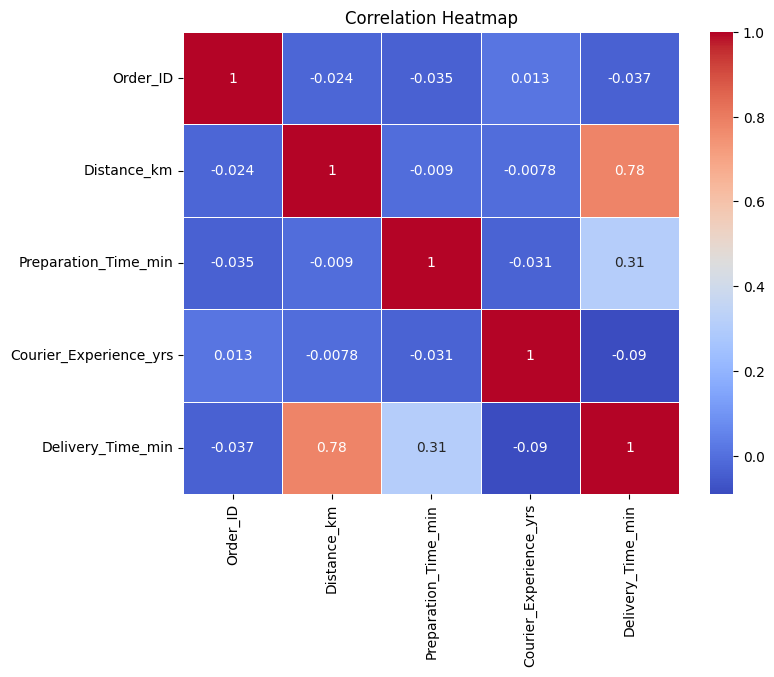

In [9]:
#Heatmap:To visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


This heatmap helps to see how different factors like distance and preparation time relate to each other and the final delivery time. The finding here is the strong relationship between Distance_km and Delivery_Time_min (scoring 0.78), which confirms that as distance increases, delivery time almost always follows. Other factors, like courier experience, show very little impact on the total time, suggesting that physical distance is the primary driver of delivery speed in this dataset.

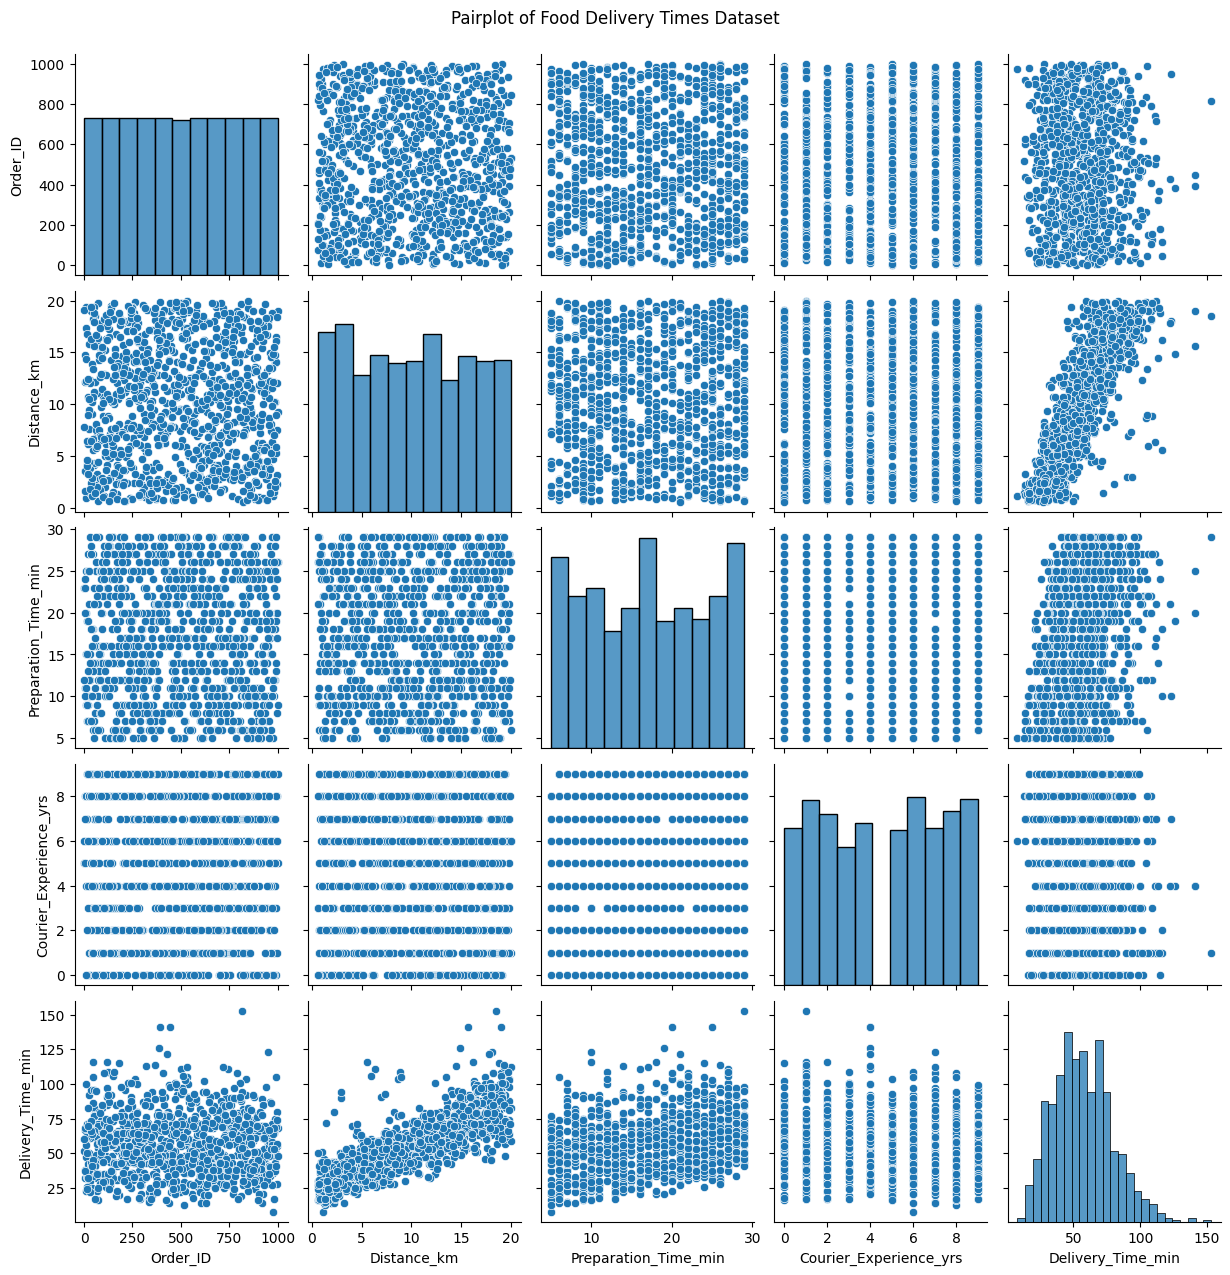

In [10]:
#2.Pairplot:  To visualize relationships between variables
sns.pairplot(df_cleaned)
plt.suptitle('Pairplot of Food Delivery Times Dataset', y=1.02)
plt.show()

The pairplot gives a view of the relationships across the entire dataset. By looking at the scatter plots in the bottom row, it can visually confirm that Delivery_Time_min has a clear upward slope when compared against Distance_km, reinforcing their strong connection. The histograms along the middle show how our data is distributed. It also shows that most delivery times fall within a specific range, while the other variables are spread out more evenly.

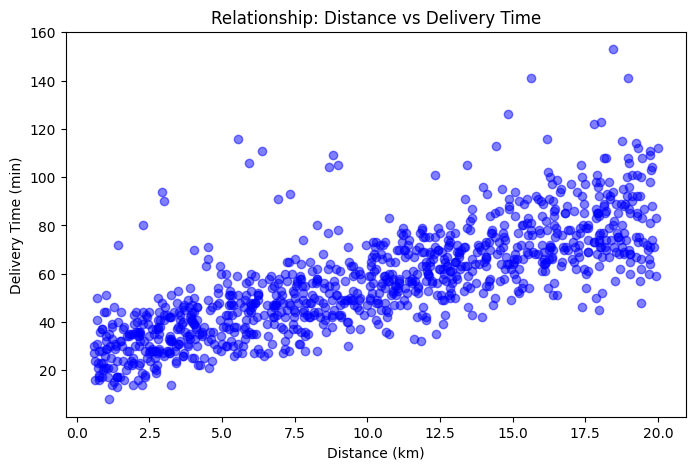

In [11]:
 #3. Scatter Plot: Distance vs Delivery Time
plt.figure(figsize=(8,5))
plt.scatter(df_cleaned['Distance_km'], df_cleaned['Delivery_Time_min'], alpha=0.5, color='blue')
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Relationship: Distance vs Delivery Time")
plt.show()

This scatter plot shows how far a courier has to travel versus how long it takes. It can clearly see a "positive trend," where the blue dots climb higher as they move to the right. While there is some short trips took a long time and some long trips were fast, the overall pattern is a straight line. This linear path makes the data a perfect visualization for a linear regression model to predict future delivery times.

EDA Interpretation:
Trend: Both Distance and Prep Time show a positive linear relationship with Delivery Time.
Suitability: The scatter plots show clear linear patterns, confirming that Linear Regression is appropriate for these two variables.
Strongest Predictor: Based on the heatmap, Distance_km has a stronger correlation with the target, meaning it has the most influence on delivery speed.


Step 4: Model Training

In [12]:
# 4.1 Define X (2 Variables) and y
X = df_cleaned[['Distance_km', 'Preparation_Time_min']]
y = df_cleaned['Delivery_Time_min']

# 4.2 Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.3 Initialize and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4.4 View Intercept and Coefficients
print("Intercept:", model.intercept_)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

Intercept: 9.530656489425084
                      Coefficient
Distance_km              3.037216
Preparation_Time_min     0.986056


Interpretation:
   The data was split into a training set (80%) and a testings set of (20%). the model trained to learn the coefficient for distance and preparation time. 
   The Intercept represents the base time required before distance and prep time are factored in.


Step 5 Performance Evaluation

MAE: 7.680351163763087
RMSE: 10.974403825674846
R-squared: 0.7313023400053361


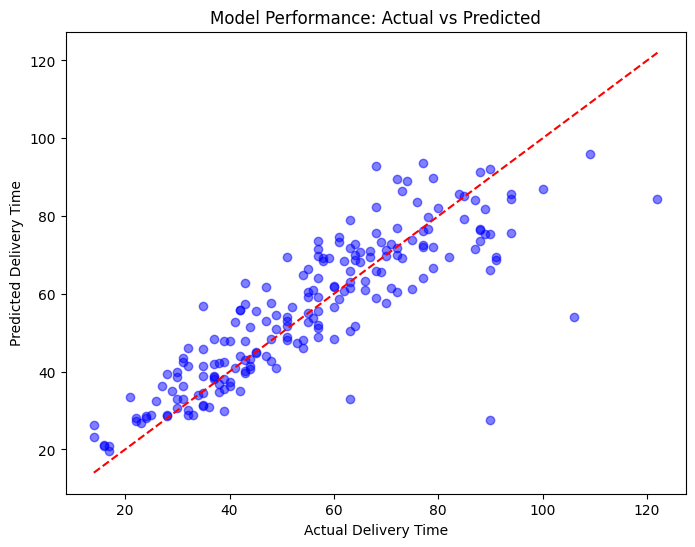

In [13]:
# 5.1 Generate Predictions
y_pred = model.predict(X_test)

# 5.2 Compute Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

# 5.3 Visualize Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Model Performance: Actual vs Predicted")
plt.show()

Interpretation:
    The R-squared score shows how well our the variables explain the delivery time. 
    The scatter plot shows the predictions are very close to the actual data (the diagonal red line), proving that even with just two variables, the model is quite reliable.

Step 6 Predict New Data

In [14]:
# Predicting a new order: Distance=5km, Prep Time=15min
new_order = pd.DataFrame({
    'Distance_km': [5],
    'Preparation_Time_min': [15]
})

prediction = model.predict(new_order)
print(f"The Predicted Delivery Time is: {prediction[0]:.2f} minutes")

The Predicted Delivery Time is: 39.51 minutes


Step 7 Reflection and Analysis

1. Do the selected variables significantly affect delivery time?
    - Yes, the R-squared score and low MAE justify that the model can predict delivery times.
2. Identify limitations of the model and dataset.
    - The model only uses two features. It ignores traffic, weather, and courier experience, which are also important.
3. Which variable contributes the most to delivery time? Justify using EDA and coefficients
    - Distance_km contributes the most, as it has a higher correlation and a larger impact on total travel time.
4. If the strongest predictor is removed, what will happen to model performance? Explain logically
    - If Distance_km were removed, the model would lose its most important signal, causing the error (RMSE) to increase significantly.
5. Does correlation imply causationin this dataset? Explain using an example.
    - Correlation implies causation here; a longer distance physically requires more travel time, directly causing the delivery time to increase.

Step 8 Export Trained Model

In [15]:
export_path = "food_delivery_model.pkl"

with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Trained model exported to food_delivery_model.pkl
